### Project Pipeline
- Project Definition : **Brain Tumor Detection**
- Data Collection : **Taken From Kaggle**
- Data Preprocessing : **Color coversion, Flip, Rotate, Brightness, Contrast, Noramalize**
- Model Type : **ConvNeXT Tiny with IMAGENET1K_V1 weights from PyTorch models**
- Evaluation : **Classification Report, Confusion Matrix**
- Saving Model
- Api for Deployment : **FastAPI**
- Testing : **Interact with Streamlit**

In [14]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from torchvision.models import ConvNeXt_Tiny_Weights
import torch.optim as optim

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import matplotlib.pyplot as plt
import seaborn as sn
import numpy as np

In [15]:
#mean and standard deviation for normalization
MEAN = (0.35)
STD = (0.48)

#for changing grayscale image to rgb
def to_rgb():
    return transforms.Lambda(lambda img: img.convert("RGB"))

In [16]:
#assigning transformation
transform = transforms.Compose([
    to_rgb(),
    transforms.Resize((300,300)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

In [17]:
#loading the data
full_dataset = datasets.ImageFolder("dataset/train", transform=transform)
full_dataset.classes

['no', 'yes']

In [18]:
#splitting data for training and testing
train_size = int(0.7 * len(full_dataset))
test_size = len(full_dataset) - train_size

train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])
len(train_dataset) #253 total

177

In [19]:
#building data loader for model training
train_loader = DataLoader(dataset=train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=8, shuffle=False)

In [20]:
#to check how transformed data is looking
def preview(img):
    np_img = img.numpy()
    plt.imshow(np.transpose(np_img, (1, 2 ,0)))
    plt.axis("off")
    plt.show()

# preview(full_dataset[19][0])

In [21]:
#settng up device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"using device: {device}")

using device: cuda


In [22]:
#loading pretrained weights
weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1

#loading model
model = models.convnext_tiny(weights=weights)

#changing head
input_dim = model.classifier[2].in_features

#changing model location to device
model.to(device)

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

In [23]:
#training function

#loss function
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

#optizier function
optimizer = optim.AdamW(model.parameters(), lr=0.0001)

#each epoch traing step
def train_step(loader):
    #changing model mode to training
    model.train(True)
    running_loss = 0.0

    #store all the prediction with one-to-one their target value
    all_predection, all_target = [],[]

    #loading batch of data form data loader
    for img, target in loader:
        img, target = img.to(device), target.to(device)

        #feeding data to model
        outputs = model(img)

        #storing loss value
        loss = criterion(outputs, target)

        #cleaning gradient
        optimizer.zero_grad()

        #back propogation
        loss.backward()

        #calculating gradient
        optimizer.step()

        #holding loss value of each data 
        running_loss += loss.item() * img.size(0)

        #hold the predicted value of single data
        predicts = outputs.argmax(1)

        #holds the prediction of each batch
        all_predection.append(predicts.cpu().numpy())

        #holds all the true value for each batch
        all_target.append(target.cpu().numpy())

    #hold loss for each epoch
    avg_loss = running_loss / len(loader.dataset)

    #holds all the true value for each epoch
    y_true = np.concatenate(all_target)
    #holds all the predicted value for each epoch
    y_pred = np.concatenate(all_predection)

    accuracy = accuracy_score(y_true, y_pred)
    f1_S = f1_score(y_true, y_pred, average="macro")

    return avg_loss, accuracy, f1_S


In [24]:
#training loop
epochs = 15

for epoch in range(epochs):
    loss, acc, f1 = train_step(train_loader)
    
    print(f"Epoch: {epoch}/{epochs}, F1: {f1}, Accuracy: {acc} ,Loss: {loss:.4f}")
    torch.cuda.empty_cache()
    if loss < 1.1:
        break
    

Epoch: 0/15, F1: 0.0831883414158615, Accuracy: 0.5875706214689266 ,Loss: 2.7969
Epoch: 1/15, F1: 0.8109560723514212, Accuracy: 0.8248587570621468 ,Loss: 1.3723
Epoch: 2/15, F1: 0.899943470887507, Accuracy: 0.9096045197740112 ,Loss: 1.2586
Epoch: 3/15, F1: 0.9753550543024228, Accuracy: 0.9774011299435028 ,Loss: 1.1180
Epoch: 4/15, F1: 0.957312661498708, Accuracy: 0.96045197740113 ,Loss: 1.1672
Epoch: 5/15, F1: 0.9755254424778761, Accuracy: 0.9774011299435028 ,Loss: 1.0795


Accuracy:  0.8947368421052632
Macro F1:  0.8935574229691876
classification_report 
               precision    recall  f1-score   support

           0       0.88      0.88      0.88        34
           1       0.90      0.90      0.90        42

    accuracy                           0.89        76
   macro avg       0.89      0.89      0.89        76
weighted avg       0.89      0.89      0.89        76

confusion matrix : 



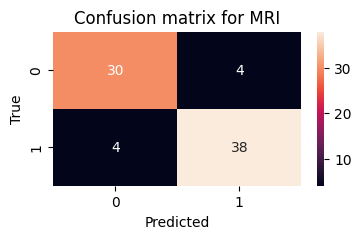

In [25]:
#evaluation
def evaluate(loader):
    model.eval()
    all_predection, all_target = [],[]

    with torch.no_grad():
        for img, target in loader:
            img = img.to(device)
            
            outputs = model(img)

            preds = outputs.argmax(1).cpu().numpy()
            
            all_predection.append(preds)
            all_target.append(target.cpu().numpy())

    y_true = np.concatenate(all_target)
    y_pred = np.concatenate(all_predection)
    cm = confusion_matrix(y_true, y_pred)
    print("Accuracy: ", accuracy_score(y_true, y_pred))
    print("Macro F1: ", f1_score(y_true, y_pred, average="macro"))
    print("classification_report \n", classification_report(y_true, y_pred))
    print("confusion matrix : \n")
    plt.figure(figsize=(4,2))
    sn.heatmap(cm, annot=True)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion matrix for MRI")

evaluate(test_loader)


In [26]:
#saving the model
#torch.save(model.state_dict(), "brain_tumor_classifier.pth")